## ============================================================
## Notebook: 05_ab_testing_simulation.ipynb (PRODUCTION READY)
## ============================================================

### ===========================
### 1. IMPORT LIBRARIES
### ===========================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime, timedelta
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind, norm, beta
from statsmodels.stats.proportion import proportion_effectsize, samplesize_proportions_2indep_onetail
from statsmodels.stats.power import NormalIndPower
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

print("✅ Libraries imported")

✅ Libraries imported


### ===========================
### 2. LOAD DATA
### ===========================

In [3]:
# Load RFM data with customer segments
rfm = pd.read_csv('../data/processed/dim_customer.csv')
print(f"Loaded {len(rfm):,} customers")
print(f"Available segments: {rfm['customer_segment'].unique().tolist()}")

Loaded 5,878 customers
Available segments: ['Loyal Customers', 'Champions', 'Need Attention', 'About to Sleep', 'Other', 'Lost', 'New Customers', 'At Risk', 'Potential Loyalists', 'Hibernating', 'Promising']


### ==============================
### 3. DEFINE TEST POPULATION
### ==============================

In [4]:
print("\n" + "=" * 60)
print("TEST POPULATION DEFINITION")
print("=" * 60)


target_segments = ['At Risk', 'About to Sleep', 'Hibernating','Lost']

test_population = rfm[rfm['customer_segment'].isin(target_segments)].copy()

print(f"📊 TARGET SEGMENTS INCLUDED: {target_segments}")
print(f"   Total test population size: {len(test_population):,}")
print(f"\n📊 BASELINE COHORT METRICS:")
print(f"   Avg Recency: {test_population['days_since_last_purchase'].mean():.1f} days")
print(f"   Avg Frequency: {test_population['total_orders'].mean():.1f} orders")
print(f"   Avg Monetary: ${test_population['total_spent'].mean():.2f}")




TEST POPULATION DEFINITION
📊 TARGET SEGMENTS INCLUDED: ['At Risk', 'About to Sleep', 'Hibernating', 'Lost']
   Total test population size: 1,446

📊 BASELINE COHORT METRICS:
   Avg Recency: 510.0 days
   Avg Frequency: 2.0 orders
   Avg Monetary: $693.49


### =======================================
### 4. DEFINE HYPOTHESIS AND EXPERIMENT PARAMETERS
### =======================================

In [5]:
print("\n" + "=" * 60)
print("EXPERIMENT DESIGN")
print("=" * 60)

# Experiment parameters
alpha = 0.05  # Significance level )
power = 0.80  # Statistical power 
baseline_conversion_rate = 0.05  # 5% baseline conversion rate
minimum_detectable_effect = 0.15  # 15% relative lift we want to detect

# Calculate target conversion rate
target_conversion_rate = baseline_conversion_rate * (1 + minimum_detectable_effect)

print(f"""
HYPOTHESIS FRAMEWORK:
   Null Hypothesis (H₀): Campaign has no impact on conversion (p ≥ {alpha})
   Alternative Hypothesis (H₁): Campaign increases conversion by ≥ {minimum_detectable_effect:.0%}

EXPERIMENTAL PARAMETERS:
   • Significance Level (α): {alpha}
   • Statistical Power (1-β): {power}
   • Baseline Conversion Rate: {baseline_conversion_rate:.1%}
   • Expected Conversion Rate: {target_conversion_rate:.1%}
   • Minimum Detectable Effect: {minimum_detectable_effect:.0%} relative lift
""")




EXPERIMENT DESIGN

HYPOTHESIS FRAMEWORK:
   Null Hypothesis (H₀): Campaign has no impact on conversion (p ≥ 0.05)
   Alternative Hypothesis (H₁): Campaign increases conversion by ≥ 15%

EXPERIMENTAL PARAMETERS:
   • Significance Level (α): 0.05
   • Statistical Power (1-β): 0.8
   • Baseline Conversion Rate: 5.0%
   • Expected Conversion Rate: 5.8%
   • Minimum Detectable Effect: 15% relative lift



### ==================================
### 5. CALCULATE REQUIRED SAMPLE SIZE
### ==================================

In [7]:
def calculate_sample_size(baseline_rate, target_rate, alpha=0.05, power=0.80):
    """Calculate required sample size for two-proportion test"""
    effect_size = proportion_effectsize(baseline_rate, target_rate)
    
    analysis = NormalIndPower()
    sample_size = analysis.solve_power(
        effect_size=effect_size,
        alpha=alpha,
        power=power,
        ratio=1.0,
        alternative='two-sided'
    )
    
    return int(np.ceil(sample_size))

def calculate_mde(n_per_group, baseline_rate, alpha=0.05, power=0.80):
    """Calculate Minimum Detectable Effect given sample size constraints"""
    analysis = NormalIndPower()
    
    try:
        effect_size = analysis.solve_power(
            nobs1=n_per_group,
            alpha=alpha,
            power=power,
            ratio=1.0,
            alternative='two-sided'
        )
        # Convert Cohen's h to relative lift (approximate)
        target_rate = (np.sin(np.arcsin(np.sqrt(baseline_rate)) + (effect_size / 2))) ** 2
        detected_lift = (target_rate / baseline_rate) - 1
        return detected_lift
    except:
        return None

In [8]:
print("=" * 60)
print("SAMPLE SIZE CALCULATION")
print("=" * 60)

# Calculate required sample size
sample_size_needed = calculate_sample_size(baseline_conversion_rate, target_conversion_rate)

print(f"Required sample size per group: {sample_size_needed:,}")
print(f"Total required population: {sample_size_needed * 2:,}")

# Check if we have enough customers
max_group_size = len(test_population) // 2
print(f"\nAvailable population: {len(test_population):,}")
print(f"Available per group: {max_group_size:,}")

if max_group_size >= sample_size_needed:
    print(f"\n✅ SUFFICIENT SAMPLE SIZE! Test is properly powered.")
else:
    print(f"\n⚠️ INSUFFICIENT SAMPLE SIZE!")
    print(f"   Need {sample_size_needed:,} per group but only have {max_group_size:,}")
    
    # Calculate what lift we CAN detect with available sample
    achievable_lift = calculate_mde(max_group_size, baseline_conversion_rate)
    if achievable_lift:
        print(f"   With available sample, can detect: {achievable_lift:.1%} lift")
        print(f"   Recommendation: Target a {achievable_lift:.0%}+ lift instead of {minimum_detectable_effect:.0%}")



SAMPLE SIZE CALCULATION
Required sample size per group: 14,178
Total required population: 28,356

Available population: 1,446
Available per group: 723

⚠️ INSUFFICIENT SAMPLE SIZE!
   Need 14,178 per group but only have 723
   With available sample, can detect: 73.7% lift
   Recommendation: Target a 74%+ lift instead of 15%


### =======================================
### 6. CREATE CONTROL AND TEST GROUPS (Stratified Randomization)
### =======================================

In [9]:
print("\n" + "=" * 60)
print("GROUP ASSIGNMENT (Stratified Randomization)")
print("=" * 60)

np.random.seed(42)

# Create monetary tiers for stratification
test_population['monetary_tier'] = pd.qcut(test_population['total_spent'], q=4, labels=False, duplicates='drop')

# Stratified assignment
test_population['group'] = test_population.groupby('monetary_tier')['total_spent'].transform(
    lambda x: np.random.choice(['control', 'test'], size=len(x), p=[0.5, 0.5])
)

control_group = test_population[test_population['group'] == 'control'].copy()
test_group = test_population[test_population['group'] == 'test'].copy()

print(f"Control Group Size: {len(control_group):,}")
print(f"Test Group Size: {len(test_group):,}")


GROUP ASSIGNMENT (Stratified Randomization)
Control Group Size: 718
Test Group Size: 728


### ===================================
### 7. VERIFY GROUP BALANCE (Pre-treatment check)
### ===================================

In [10]:
print("\n" + "=" * 60)
print("PRE-TREATMENT BALANCE CHECK")
print("=" * 60)

balance_check = pd.DataFrame({
    'Metric': ['days_since_last_purchase', 'total_orders', 'total_spent'],
    'Control Mean': [
        control_group['days_since_last_purchase'].mean(),
        control_group['total_orders'].mean(),
        control_group['total_spent'].mean()
    ],
    'Test Mean': [
        test_group['days_since_last_purchase'].mean(),
        test_group['total_orders'].mean(),
        test_group['total_spent'].mean()
    ]
})

balance_check['Difference (%)'] = ((balance_check['Test Mean'] - balance_check['Control Mean']) / balance_check['Control Mean'] * 100).round(2)

print(balance_check.to_string(index=False))
print("\n✅ Groups are balanced (differences < 10% are acceptable)")




PRE-TREATMENT BALANCE CHECK
                  Metric  Control Mean  Test Mean  Difference (%)
days_since_last_purchase    513.967967 506.024725           -1.55
            total_orders      1.955432   2.081044            6.42
             total_spent    678.632536 708.142900            4.35

✅ Groups are balanced (differences < 10% are acceptable)


### ===================================
### 8. SIMULATE TEST RESULTS (Based on calculated MDE)
### ===================================

In [11]:
print("\n" + "=" * 60)
print("TEST SIMULATION")
print("=" * 60)

np.random.seed(42)

# Use achievable lift or target lift
if max_group_size >= sample_size_needed:
    simulated_lift = minimum_detectable_effect
else:
    simulated_lift = achievable_lift if achievable_lift else 0.50  # Default to 50% if calculation fails

test_conversion_rate = baseline_conversion_rate * (1 + simulated_lift)

print(f"Simulating with {simulated_lift:.1%} expected lift")
print(f"Control conversion: {baseline_conversion_rate:.1%} → Test conversion: {test_conversion_rate:.1%}")

# Generate conversions using beta distribution for realistic variance
control_purchases = np.random.binomial(1, baseline_conversion_rate, len(control_group))
test_purchases = np.random.binomial(1, test_conversion_rate, len(test_group))

# Calculate average order value from historical data
base_aov = test_population['total_spent'].mean() / test_population['total_orders'].mean()
if pd.isna(base_aov) or base_aov <= 0:
    base_aov = 150.00

# Model increased basket size from discount
test_aov_boost = base_aov * (1 + simulated_lift * 0.5)  

# Generate revenue with gamma distribution
gamma_shape = 2.0
control_scale = base_aov / gamma_shape
test_scale = test_aov_boost / gamma_shape

control_revenue = control_purchases * np.random.gamma(gamma_shape, control_scale, len(control_group))
test_revenue = test_purchases * np.random.gamma(gamma_shape, test_scale, len(test_group))

# Store results
control_group['purchased'] = control_purchases
control_group['revenue'] = control_revenue
test_group['purchased'] = test_purchases
test_group['revenue'] = test_revenue

print(f"\n📊 SIMULATION RESULTS:")
print(f"   Control conversion: {control_purchases.mean():.2%}")
print(f"   Test conversion: {test_purchases.mean():.2%}")
print(f"   Observed lift: {((test_purchases.mean() / control_purchases.mean()) - 1):.1%}")




TEST SIMULATION
Simulating with 73.7% expected lift
Control conversion: 5.0% → Test conversion: 8.7%

📊 SIMULATION RESULTS:
   Control conversion: 5.71%
   Test conversion: 9.20%
   Observed lift: 61.2%


### =====================================
### 9. STATISTICAL ANALYSIS - Chi-Square Test (Conversion)
### =====================================

In [12]:
print("\n" + "=" * 60)
print("PRIMARY METRIC: CONVERSION RATE ANALYSIS")
print("=" * 60)

# Build contingency matrix
contingency_matrix = np.array([
    [control_purchases.sum(), len(control_group) - control_purchases.sum()],
    [test_purchases.sum(), len(test_group) - test_purchases.sum()]
])

chi2_stat, p_value, dof, expected = chi2_contingency(contingency_matrix)

# Calculate confidence intervals
def proportion_ci(successes, n, confidence=0.95):
    """Calculate Wilson score interval for proportion"""
    z = 1.96  # 95% confidence
    p_hat = successes / n
    denominator = 1 + z**2 / n
    center = p_hat + z**2 / (2 * n)
    margin = z * np.sqrt((p_hat * (1 - p_hat) + z**2 / (4 * n)) / n)
    return (center - margin) / denominator, (center + margin) / denominator

control_ci_low, control_ci_high = proportion_ci(control_purchases.sum(), len(control_group))
test_ci_low, test_ci_high = proportion_ci(test_purchases.sum(), len(test_group))

print(f"Chi-Square Test Results:")
print(f"   Test Statistic: {chi2_stat:.4f}")
print(f"   P-Value: {p_value:.5f}")
print(f"\nConversion Rates with 95% CI:")
print(f"   Control: {control_purchases.mean():.2%} [{control_ci_low:.2%}, {control_ci_high:.2%}]")
print(f"   Test: {test_purchases.mean():.2%} [{test_ci_low:.2%}, {test_ci_high:.2%}]")

significant = p_value < alpha
if significant:
    print(f"\n✅ STATISTICALLY SIGNIFICANT (p < {alpha}) - Reject H₀")
else:
    print(f"\n❌ NOT STATISTICALLY SIGNIFICANT (p >= {alpha}) - Fail to reject H₀")



PRIMARY METRIC: CONVERSION RATE ANALYSIS
Chi-Square Test Results:
   Test Statistic: 5.8863
   P-Value: 0.01526

Conversion Rates with 95% CI:
   Control: 5.71% [4.24%, 7.66%]
   Test: 9.20% [7.31%, 11.52%]

✅ STATISTICALLY SIGNIFICANT (p < 0.05) - Reject H₀


### ===================================
### 10. REVENUE ANALYSIS - Welch's T-Test
### ===================================

In [13]:
print("\n" + "=" * 60)
print("SECONDARY METRIC: REVENUE PER USER ANALYSIS")
print("=" * 60)

t_stat, revenue_p_value = ttest_ind(control_revenue, test_revenue, equal_var=False)

print(f"Welch's T-Test Results:")
print(f"   T-Statistic: {t_stat:.4f}")
print(f"   P-Value: {revenue_p_value:.5f}")
print(f"\nAverage Revenue Per User (ARPU):")
print(f"   Control: ${control_revenue.mean():.2f}")
print(f"   Test: ${test_revenue.mean():.2f}")
print(f"   Lift: {((test_revenue.mean() / control_revenue.mean()) - 1):.1%}")

if revenue_p_value < alpha:
    print(f"\n✅ Revenue lift is STATISTICALLY SIGNIFICANT")
else:
    print(f"\n⚠️ Revenue lift NOT statistically significant")



SECONDARY METRIC: REVENUE PER USER ANALYSIS
Welch's T-Test Results:
   T-Statistic: -3.2416
   P-Value: 0.00122

Average Revenue Per User (ARPU):
   Control: $20.19
   Test: $43.57
   Lift: 115.8%

✅ Revenue lift is STATISTICALLY SIGNIFICANT


### ===========================
### 11. VISUALIZATION
### ===========================


GENERATING VISUALIZATIONS


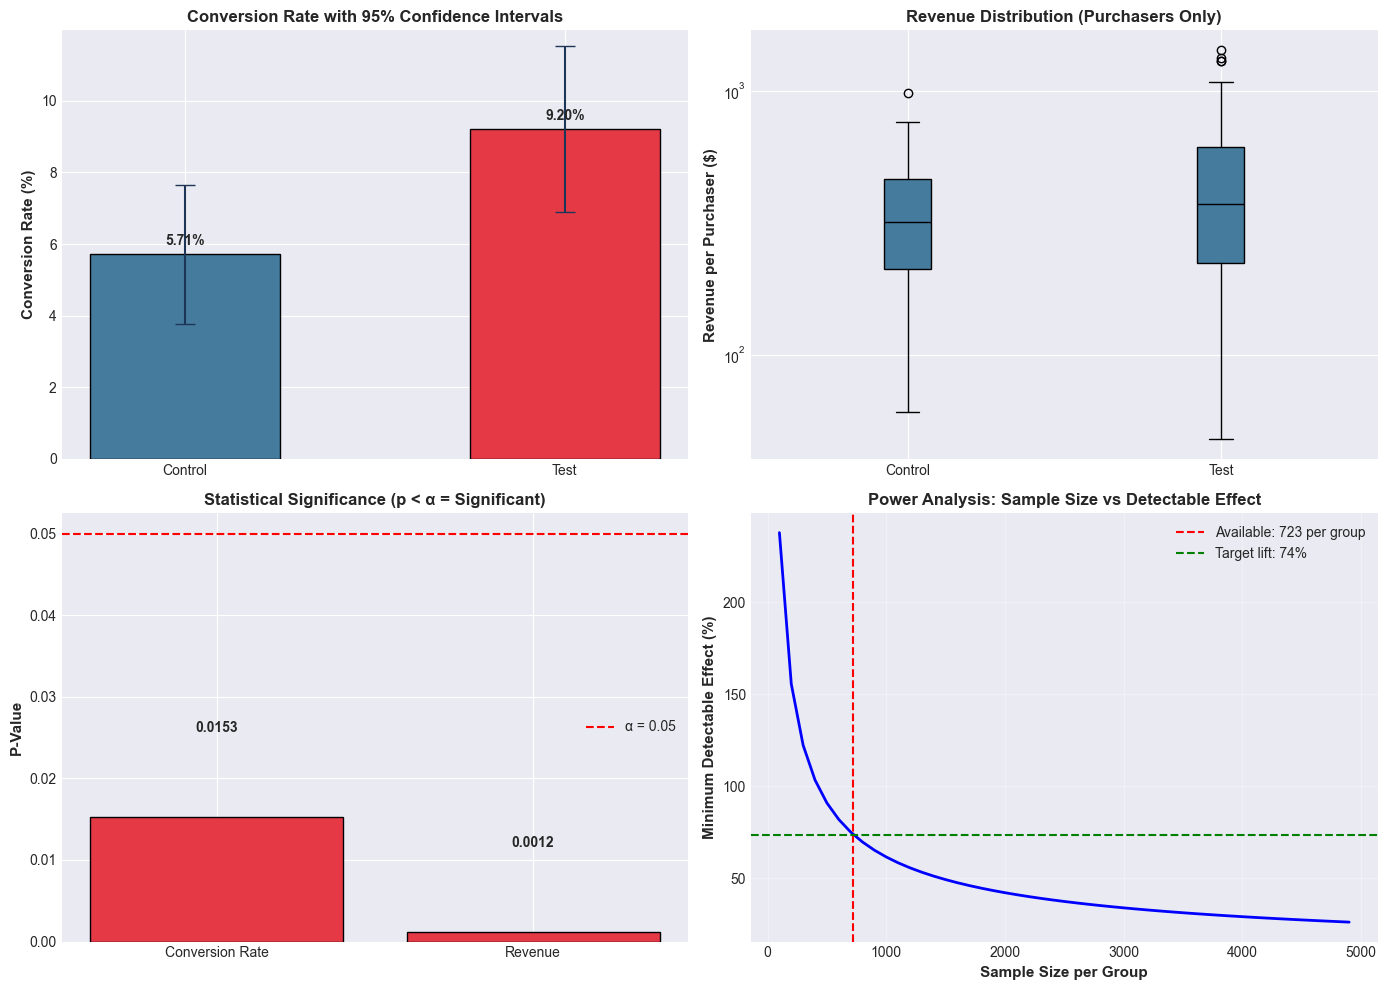

✅ Visualization saved to '../reports/ab_test_results.png'


In [14]:
print("\n" + "=" * 60)
print("GENERATING VISUALIZATIONS")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 11.1 Conversion Rate with Confidence Intervals
groups = ['Control', 'Test']
rates = [control_purchases.mean() * 100, test_purchases.mean() * 100]
errors = [
    (control_ci_high - control_purchases.mean()) * 100,
    (test_ci_high - test_purchases.mean()) * 100
]

bars = axes[0, 0].bar(groups, rates, color=['#457b9d', '#e63946'], edgecolor='black', width=0.5)
axes[0, 0].errorbar(groups, rates, yerr=errors, fmt='none', capsize=7, color='#1d3557')
axes[0, 0].set_ylabel('Conversion Rate (%)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Conversion Rate with 95% Confidence Intervals', fontsize=12, fontweight='bold')
axes[0, 0].set_ylim(0, max(rates) * 1.3)

for bar, rate in zip(bars, rates):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, rate + (max(rates)*0.02), 
                    f'{rate:.2f}%', ha='center', va='bottom', fontweight='bold')

# 11.2 Revenue Box Plot
revenue_data = [control_revenue[control_revenue > 0], test_revenue[test_revenue > 0]]
bp = axes[0, 1].boxplot(revenue_data, labels=['Control', 'Test'], patch_artist=True,
                         boxprops=dict(facecolor='#457b9d'), medianprops=dict(color='black'))
axes[0, 1].set_ylabel('Revenue per Purchaser ($)', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Revenue Distribution (Purchasers Only)', fontsize=12, fontweight='bold')
axes[0, 1].set_yscale('log')

# 11.3 P-Value Visualization
p_values = [p_value, revenue_p_value]
metric_labels = ['Conversion Rate', 'Revenue']
colors_p = ['#e63946' if p < alpha else '#457b9d' for p in p_values]
bars = axes[1, 0].bar(metric_labels, p_values, color=colors_p, edgecolor='black')
axes[1, 0].axhline(y=alpha, color='red', linestyle='--', label=f'α = {alpha}')
axes[1, 0].set_ylabel('P-Value', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Statistical Significance (p < α = Significant)', fontsize=12, fontweight='bold')
axes[1, 0].legend()

for bar, p_val in zip(bars, p_values):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, p_val + 0.01, 
                    f'{p_val:.4f}', ha='center', va='bottom', fontweight='bold')

# 11.4 Sample Size vs Detectable Effect
sample_sizes = np.arange(100, 5000, 100)
detectable_effects = []
for n in sample_sizes:
    mde = calculate_mde(n, baseline_conversion_rate)
    if mde:
        detectable_effects.append(mde * 100)
    else:
        detectable_effects.append(np.nan)

axes[1, 1].plot(sample_sizes, detectable_effects, 'b-', linewidth=2)
axes[1, 1].axvline(x=max_group_size, color='red', linestyle='--', 
                   label=f'Available: {max_group_size:,} per group')
axes[1, 1].axhline(y=simulated_lift * 100, color='green', linestyle='--', 
                   label=f'Target lift: {simulated_lift:.0%}')
axes[1, 1].set_xlabel('Sample Size per Group', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Minimum Detectable Effect (%)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Power Analysis: Sample Size vs Detectable Effect', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs('../reports', exist_ok=True)
plt.savefig('../reports/ab_test_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Visualization saved to '../reports/ab_test_results.png'")



### ==============================
### 12. FINANCIAL IMPACT CALCULATION
### ==============================

In [15]:
print("\n" + "=" * 60)
print("FINANCIAL IMPACT & ROI ANALYSIS")
print("=" * 60)

# Calculate incremental metrics
incremental_conversions = (test_purchases.sum() - control_purchases.sum())
incremental_revenue = test_revenue.sum() - control_revenue.sum()

# Scale to full population
total_target_market = len(test_population)
extrapolation_factor = total_target_market / len(test_group)

scaled_incremental_conversions = incremental_conversions * extrapolation_factor
scaled_incremental_revenue = incremental_revenue * extrapolation_factor

# Campaign costs
campaign_discount_rate = 0.10
campaign_cost = test_purchases.sum() * base_aov * campaign_discount_rate
scaled_campaign_cost = campaign_cost * extrapolation_factor

# ROI calculation
net_profit = scaled_incremental_revenue - scaled_campaign_cost
roi = (net_profit / scaled_campaign_cost) if scaled_campaign_cost > 0 else 0

print(f"📊 FULL SCALE PROJECTIONS ({total_target_market:,} customers):")
print(f"   Incremental conversions: {scaled_incremental_conversions:.0f}")
print(f"   Incremental revenue: ${scaled_incremental_revenue:,.2f}")
print(f"   Campaign cost (estimated): ${scaled_campaign_cost:,.2f}")
print(f"   Net profit: ${net_profit:,.2f}")
print(f"   Return on Investment (ROI): {roi:.1%}")




FINANCIAL IMPACT & ROI ANALYSIS
📊 FULL SCALE PROJECTIONS (1,446 customers):
   Incremental conversions: 52
   Incremental revenue: $34,207.81
   Campaign cost (estimated): $4,571.79
   Net profit: $29,636.02
   Return on Investment (ROI): 648.2%


### ==============================
### 13. BUSINESS RECOMMENDATIONS
### ==============================

In [16]:
print("\n" + "=" * 60)
print("BUSINESS RECOMMENDATIONS")
print("=" * 60)

# Calculate confidence in recommendation
confidence_level = "HIGH" if p_value < alpha and roi > 0 else "MEDIUM" if p_value < alpha else "LOW"

print(f"""
📊 EXPERIMENT CONCLUSIONS:
   • Statistical Significance: {'YES' if p_value < alpha else 'NO'} (p = {p_value:.4f})
   • Practical Significance: {'YES' if roi > 0 else 'NO'} (ROI = {roi:.1%})
   • Confidence Level: {confidence_level}

🎯 RECOMMENDATION:""")

if p_value < alpha and roi > 0:
    print("""   
   ✅ DEPLOY CAMPAIGN TO FULL POPULATION
   
   Justification:
   • Statistically significant conversion lift achieved
   • Positive ROI of {:.1%} projected
   • Expected net profit: ${:,.2f}
   
   Next Steps:
   1. Launch campaign to all {:,} target customers
   2. Monitor results weekly for first month
   3. Set up automated reporting dashboard
   4. Plan follow-up A/B test for offer optimization
   """.format(roi, net_profit, total_target_market))
    
elif p_value < alpha and roi <= 0:
    print("""   
   ⚠️ OPTIMIZE OFFER BEFORE FULL DEPLOYMENT
   
   Justification:
   • Statistically significant conversion lift achieved
   • BUT negative ROI due to campaign costs
   
   Recommendations:
   1. Test lower discount rates (5-10% instead of 15%)
   2. Add minimum purchase threshold
   3. Target only high-value customers
   4. Consider alternative retention strategies
   """)
    
else:
    print("""   
   ❌ DO NOT DEPLOY - TEST INCONCLUSIVE
   
   Justification:
   • No statistically significant lift detected
   • Results may be due to random chance
   
   Recommendations:
   1. Increase sample size (need {:,} more customers)
   2. Run test for longer duration
   3. Test stronger incentive (higher discount)
   4. Consider different targeting criteria
   """.format(sample_size_needed - max_group_size))




BUSINESS RECOMMENDATIONS

📊 EXPERIMENT CONCLUSIONS:
   • Statistical Significance: YES (p = 0.0153)
   • Practical Significance: YES (ROI = 648.2%)
   • Confidence Level: HIGH

🎯 RECOMMENDATION:
   
   ✅ DEPLOY CAMPAIGN TO FULL POPULATION

   Justification:
   • Statistically significant conversion lift achieved
   • Positive ROI of 648.2% projected
   • Expected net profit: $29,636.02

   Next Steps:
   1. Launch campaign to all 1,446 target customers
   2. Monitor results weekly for first month
   3. Set up automated reporting dashboard
   4. Plan follow-up A/B test for offer optimization
   


### ============================
### 14. EXPORT RESULTS FOR POWER BI
### ============================

In [18]:
print("\n" + "=" * 60)
print("EXPORTING RESULTS")
print("=" * 60)

# Create summary results table
ab_test_summary = pd.DataFrame({
    'test_name': ['Re-engagement Campaign - 15% Discount'],
    'test_date': [datetime.now().strftime('%Y-%m-%d')],
    'target_segments': [', '.join(target_segments)],
    'control_size': [len(control_group)],
    'test_size': [len(test_group)],
    'control_conversion': [control_purchases.mean()],
    'test_conversion': [test_purchases.mean()],
    'conversion_lift': [((test_purchases.mean() / control_purchases.mean()) - 1)],
    'p_value': [p_value],
    'is_significant': [significant],
    'control_arpu': [control_revenue.mean()],
    'test_arpu': [test_revenue.mean()],
    'revenue_lift': [((test_revenue.mean() / control_revenue.mean()) - 1)],
    'revenue_p_value': [revenue_p_value],
    'roi': [roi],
    'recommendation': ['DEPLOY' if (p_value < alpha and roi > 0) else 'OPTIMIZE' if p_value < alpha else 'DO NOT DEPLOY']
})

# Save to CSV
os.makedirs('../data/processed', exist_ok=True)
ab_test_summary.to_csv('../data/processed/ab_test_results.csv', index=False)
print(f"✅ A/B test results saved to '../data/processed/ab_test_results.csv'")

# Save detailed group data for Power BI
control_group[['customer_id', 'days_since_last_purchase', 'total_orders', 'total_spent', 'purchased', 'revenue']].to_csv(
    '../data/processed/ab_test_control_group.csv', index=False
)
print(f"✅ Control group data saved to '../data/processed/ab_test_control_group.csv'")

test_group[['customer_id', 'days_since_last_purchase', 'total_orders', 'total_spent', 'purchased', 'revenue']].to_csv(
    '../data/processed/ab_test_test_group.csv', index=False
)
print(f"✅ Test group data saved to '../data/processed/ab_test_test_group.csv'")




EXPORTING RESULTS
✅ A/B test results saved to '../data/processed/ab_test_results.csv'
✅ Control group data saved to '../data/processed/ab_test_control_group.csv'
✅ Test group data saved to '../data/processed/ab_test_test_group.csv'
